In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [30]:
start= '2020-01-01'
end= '2025-12-21'

stock= 'GOOG'

data= yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [33]:
data.reset_index(inplace=True)

In [34]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2020-01-02,67.811752,67.849937,66.531265,66.531265,28132000
1,2020-01-03,67.478996,68.066178,66.729352,66.844208,23728000
2,2020-01-06,69.142853,69.256415,66.950350,66.950350,34646000
3,2020-01-07,69.099701,69.578270,68.952903,69.327831,30054000
4,2020-01-08,69.644234,70.004277,68.975719,69.037210,30560000
...,...,...,...,...,...,...
1496,2025-12-15,309.102234,312.479859,305.524737,312.404900,22028900
1497,2025-12-16,307.513367,311.625460,303.616088,305.784574,21285200
1498,2025-12-17,297.850159,308.977329,297.240603,308.792462,29120400


In [35]:
ma_100_days= data.Close.rolling(100).mean()

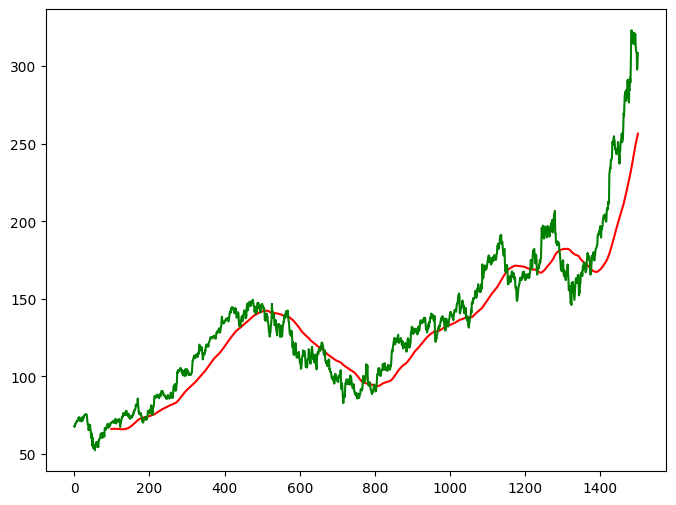

In [36]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [37]:
ma_200_days= data.Close.rolling(200).mean()

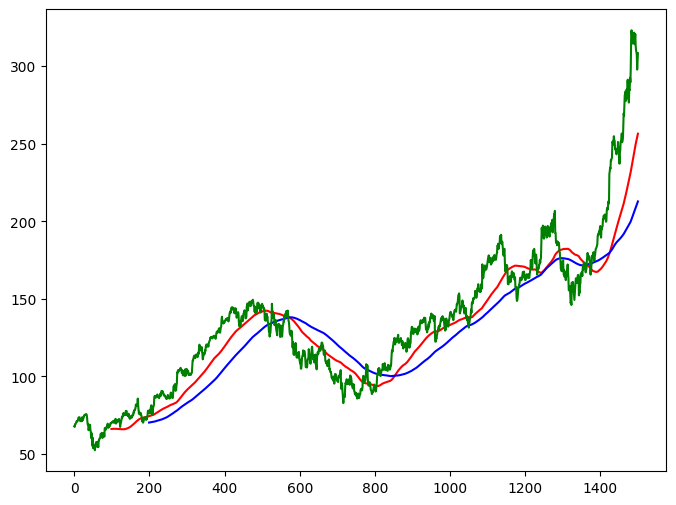

In [39]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days, 'b')
plt.plot(data.Close, 'g')
plt.show()

In [40]:
data.dropna(inplace=True)

In [48]:
data_train = pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test  = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [49]:
data_train.shape[0]

1200

In [50]:
data_test.shape[0]

301

In [51]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler(feature_range=(0,1))

In [52]:
data_train_scale= scaler.fit_transform(data_train)

In [53]:
x=[]
y=[]

for i in range (100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [62]:
x, y=np.array(x), np.array(y)

In [63]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [64]:
model= Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units= 60, activation='relu', return_sequences= True))
model.add(Dropout(0.3))

model.add(LSTM(units= 80, activation='relu',return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units= 120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units= 1))


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [65]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [66]:
model.fit(x,y,epochs=50, batch_size=32, verbose=1)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - loss: 0.0714
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - loss: 0.0152
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 0.0098
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - loss: 0.0102
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - loss: 0.0098
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - loss: 0.0085
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - loss: 0.0077
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - loss: 0.0079
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - loss: 0.0082
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 241ms/step - loss: 0.0077
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - loss: 0.0070
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - loss: 0.0071
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - loss: 0.0065
Epoch 14/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - loss: 0.0073
Epoch 15/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - l

In [67]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 1, 50)               │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 1, 60)               │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 1, 60)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 1, 80)               │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1, 80)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [68]:
pas_100_days= data_train.tail(100)

In [69]:
data_test= pd.concat([pas_100_days, data_test], ignore_index=True)

In [71]:
data_test_scale= scaler.fit_transform(data_test)

In [75]:
x=[]
y=[]

for i in range (100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y= np.array(x), np.array(y)

In [76]:
y_predict= model.predict(x)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step


In [80]:
scale=1/scaler.scale_

In [81]:
y_predict= y_predict*scale

In [82]:
y=y*scale

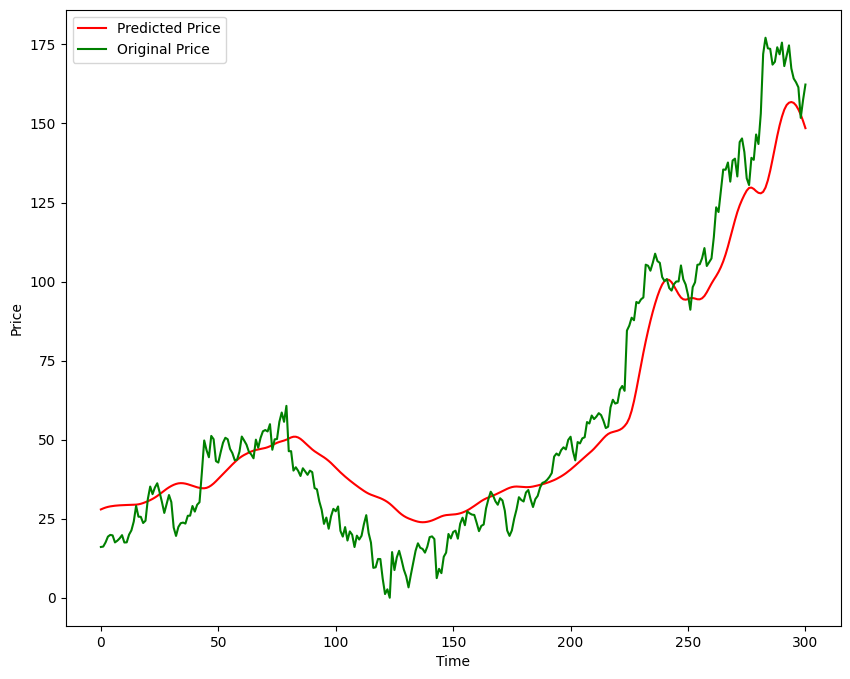

In [85]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label= 'Predicted Price')
plt.plot(y, 'g', label= 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [86]:
model.save('Stock Predictions Model.keras')